In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
train_data = pd.read_csv(r'/home/void/Desktop/Folder/QBC/NLP/Datas/train_data.csv')

/tmp/ipykernel_7885/3006466766.py:1: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv(r'/home/void/Desktop/Folder/QBC/NLP/Datas/train_data.csv')


In [4]:
train_data.head()

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,2,NaN,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400
1,5,NaN,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200
2,4,NaN,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000
3,5,NaN,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,I got tired of the remote being on the wrong s...,Same as TWC remote,1452729600
4,5,NaN,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,After purchasing cheap cords from another webs...,Good Quality Cord,1476921600


In [52]:
train_data['vote'] = (
    train_data['vote']
    .astype(str)
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype('int64')
)

In [6]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 838944 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   overall         838944 non-null  int64
 1   vote            838944 non-null  int64
 2   verified        838944 non-null  bool 
 3   reviewTime      838944 non-null  str  
 4   reviewerID      838944 non-null  str  
 5   asin            838944 non-null  str  
 6   style           490613 non-null  str  
 7   reviewerName    838717 non-null  str  
 8   reviewText      838944 non-null  str  
 9   summary         838868 non-null  str  
 10  unixReviewTime  838944 non-null  int64
dtypes: bool(1), int64(3), str(7)
memory usage: 64.8 MB


#### vote, style, reviewerName and summary has Nan values first we will clean in up

In [7]:
train_data['overall']

0         2
1         5
2         4
3         5
4         5
         ..
838939    5
838940    1
838941    3
838942    5
838943    5
Name: overall, Length: 838944, dtype: int64

In [8]:
counts = train_data['overall'].value_counts()

The plot of the overall distro

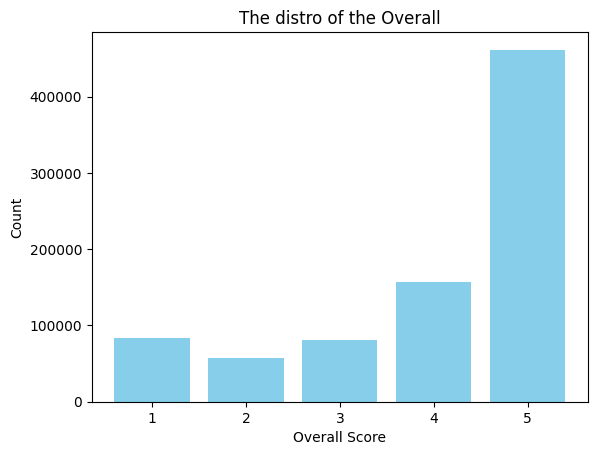

In [9]:
plt.bar(counts.index,
        counts.values,
        color = 'skyblue'
        )
plt.title('The distro of the Overall')
plt.xlabel('Overall Score')
plt.ylabel('Count')
plt.show()

### As we can see it is not balance:
#### for the solution of this imbalancment i prefer to just use the half of the 5 score datas

#### create the word cloud

#### The complete wordcloud

In [10]:
import re
from wordcloud import STOPWORDS, WordCloud
import matplotlib.pyplot as plt
# clean the text
text = ' '.join(train_data['reviewText'].astype(str).tolist())
text = re.sub(r'^A-Za-z\s','',text)
stopwords = set(STOPWORDS)
text = ' '.join(word for word in text.split() if word not in stopwords)

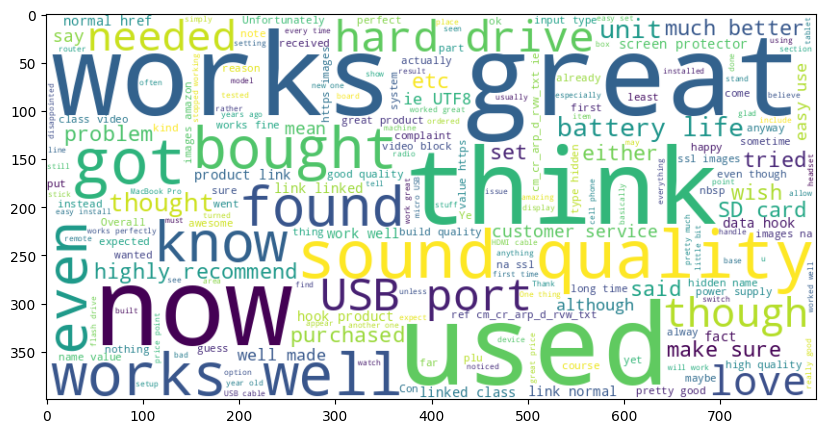

In [11]:
wordcloud = WordCloud(width=800,height=400,
                      background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.show()

#### the positive wordcloud

In [16]:
positive = train_data[train_data['overall'].isin([4,5])]
# clean the text
text_p = ' '.join(positive['reviewText'].astype(str).tolist())
text_p = re.sub(r'^A-Za-z\s','',text_p)
stopwords = set(STOPWORDS)
text_p = ' '.join(word for word in text_p.split() if word not in stopwords)

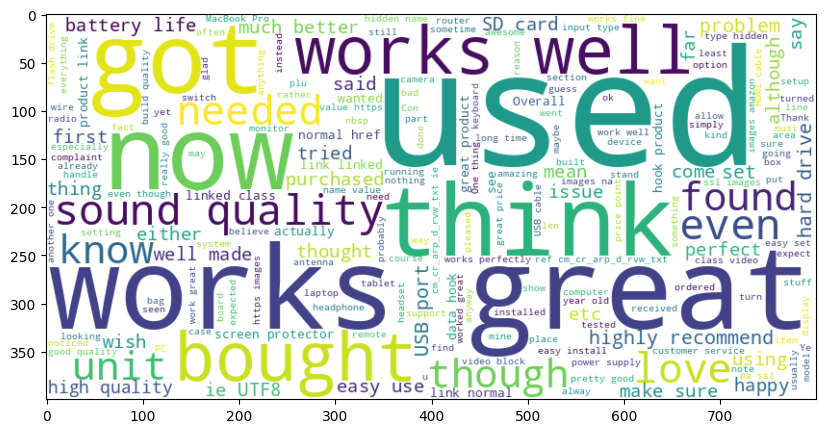

In [17]:
wordcloud = WordCloud(width=800,height=400,
                      background_color='white').generate(text_p)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.show()

#### the neutral wordcloud

In [18]:
neutral = train_data[train_data['overall'].isin([3])]
# clean the text
text_ne = ' '.join(neutral['reviewText'].astype(str).tolist())
text_ne = re.sub(r'^A-Za-z\s','',text_ne)
stopwords = set(STOPWORDS)
text_ne = ' '.join(word for word in text_ne.split() if word not in stopwords)

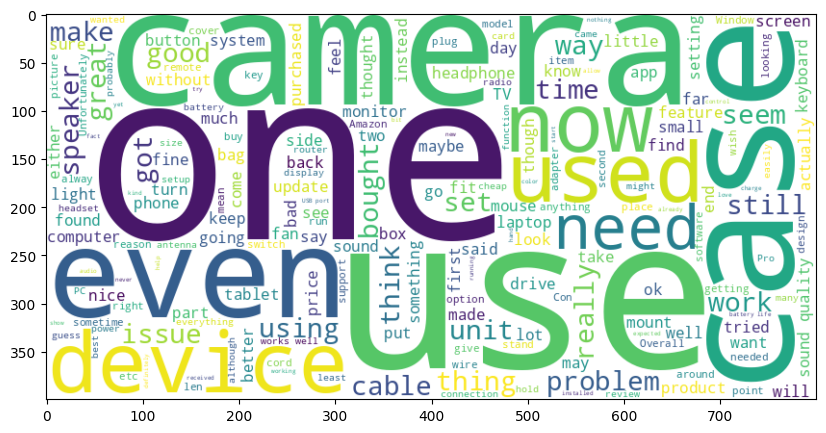

In [19]:
wordcloud = WordCloud(width=800,height=400,
                      background_color='white').generate(text_ne)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.show()

#### the Negative wordcloud

In [20]:
negative = train_data[train_data['overall'].isin([1,2])]
# clean the text
text_n = ' '.join(negative['reviewText'].astype(str).tolist())
text_n = re.sub(r'^A-Za-z\s','',text_n)
stopwords = set(STOPWORDS)
text_n = ' '.join(word for word in text_n.split() if word not in stopwords)

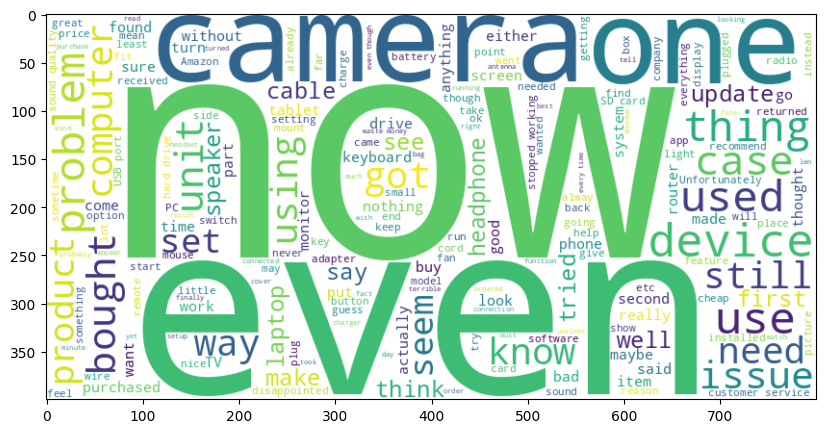

In [21]:
wordcloud = WordCloud(width=800,height=400,
                      background_color='white').generate(text_n)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.show()

In [53]:
top_voters = train_data.groupby('reviewerID')['vote'].sum()
top10 = top_voters.sort_values(ascending=False)
top10.head(10)

reviewerID
A25GROL6KJV3QG    4572
A3KJ0DF3LTNJ6X    3181
A2IK776FY6MEMG    3150
A1KPFZCS71QKW5    2978
AMYCUX8EWEUVV     2631
ADLVFFE4VBT8      2607
A1GHPJB2N0D0RL    2167
AW7UMXXJKFSNS     1912
A33AN9NP6574M2    1867
A2VQ0V1TWXF3U7    1820
Name: vote, dtype: int64

(array([8.32796e+05, 5.40000e+03, 5.60000e+02, 1.30000e+02, 3.20000e+01,
        1.80000e+01, 5.00000e+00, 3.00000e+00]),
 array([  200.  ,  3818.25,  7436.5 , 11054.75, 14673.  , 18291.25,
        21909.5 , 25527.75, 29146.  ]),
 <BarContainer object of 8 artists>)

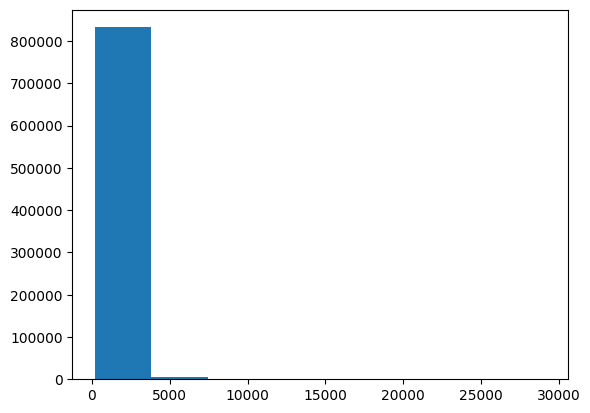

In [4]:
train_data['len_review'] = train_data['reviewText'].str.len()
# train_data['len_review']
plt.hist(train_data['len_review'],bins=8)

#### Remove the outlier

(array([326536., 168038.,  98543.,  62509.,  42554.,  30524.,  22350.,
         16497.]),
 array([ 200.  ,  340.75,  481.5 ,  622.25,  763.  ,  903.75, 1044.5 ,
        1185.25, 1326.  ]),
 <BarContainer object of 8 artists>)

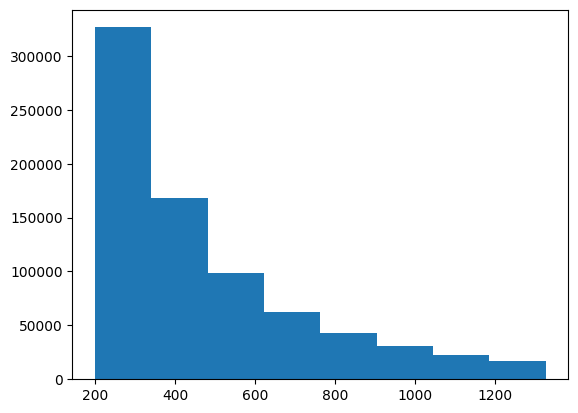

In [7]:
Q1 = train_data['len_review'].quantile(0.25)
Q3 = train_data['len_review'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

upper_arr = np.where(train_data['len_review'] >= upper)[0]
lower_arr = np.where(train_data['len_review'] <= lower)[0]

temp = train_data.copy()
temp.drop(index=upper_arr,inplace=True)
temp.drop(index=lower_arr,inplace=True)

plt.hist(temp['len_review'],bins = 8)

In [54]:
train_data.head()

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,len_review
0,2,0,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400,561
1,5,0,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200,450
2,4,0,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000,205
3,5,0,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,I got tired of the remote being on the wrong s...,Same as TWC remote,1452729600,284
4,5,0,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,After purchasing cheap cords from another webs...,Good Quality Cord,1476921600,247


In [ ]:
top_product = train_data.groupby(['asin'])['overall'].sum()
top = top_product.sort_values(ascending=False)
top_10_product = top.head(10)

In [26]:
negasht = pd.read_csv(r'/home/void/Desktop/Folder/QBC/NLP/Datas/title_brand.csv')
negasht

,asin,title,brand
0,0011300000,Genuine Geovision 1 Channel 3rd Party NVR IP S...,GeoVision
1,0043396828,"Books ""Handbook of Astronomical Image Processi...",33 Books Co.
2,0060009810,One Hot Summer,Visit Amazon's Carolina Garcia Aguilera Page
3,0060219602,Hurray for Hattie Rabbit: Story and pictures (...,Visit Amazon's Dick Gackenbach Page
4,0060786817,sex.lies.murder.fame.: A Novel,Visit Amazon's Lolita Files Page
...,...,...,...
786440,B01HJGOOMW,Tukzer Cassette Player Portable Tape Player Ca...,Tukzer
786441,B01HJH3XLE,Cobiter AC Adapter Battery Charger For IBM LEN...,Cobiter
786442,B01HJH6CEY,Baofeng Original Li-ion Battery Charger Deskto...,COOLBOY
786443,B01HJH40WU,Jricoo 3pack 6ft Micro USB to USB Cable 2.0 6f...,Jricoo


In [30]:
negasht['asin']

0         0011300000
1         0043396828
2         0060009810
3         0060219602
4         0060786817
             ...    
786440    B01HJGOOMW
786441    B01HJH3XLE
786442    B01HJH6CEY
786443    B01HJH40WU
786444    B01HJH42KU
Name: asin, Length: 786445, dtype: str

In [45]:
# mask = negasht['asin'].isin(top_10_product)
# top10negasht = negasht[mask]
# top10negasht
print(negasht['asin'].dtype)
print(top_10_product.dtype)

str
int64


In [48]:
# mask = negasht['asin'].isin(top_10_product)
# top10negasht = negasht[mask]
# top10negasht

negasht['asin'] = negasht['asin'].astype(str)
top_10_product = top_10_product.astype(str)

top10negasht = negasht[negasht['asin'].isin(top_10_product.index)]
top10negasht

,asin,title,brand
112279,B000VS4HDM,StarTech USB 2.0 to SATA IDE Adapter (USB2SATA...,StarTech
200321,B0043T7FXE,Logitech M570 Wireless Trackball Mouse &ndash;...,Logitech
392864,B00DIF2BO2,Cheetah Mounts APFMSB TV Wall Mount Bracket fo...,Cheetah
491863,B00JX1ZS5O,Sabrent 4-Port USB 3.0 Hub with Individual LED...,Sabrent
509009,B00L0YLRUW,NETGEAR N300 WiFi Range Extender (EX2700),NETGEAR
552025,B00OBRE5UE,Samsung 850 EVO 500GB 2.5-Inch SATA III Intern...,Samsung
561412,B00P7EVST6,Arlo - Wireless Home Security Camera System | ...,"Arlo Technologies, Inc"
587299,B00S9SGNNS,ASUS Tri-Band Gigabit (AC3200) WiFi Router (Up...,Asus
647906,B010OYASRG,OontZ Angle 3 Enhanced Stereo Edition IPX5 Spl...,Cambridge Soundworks
747109,B01DA0YCNC,Roku Streaming Stick (3600R) - HD Streaming Pl...,Roku


In [55]:
final_df = pd.merge(train_data,negasht,on='asin')
final_df

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,len_review,title,brand
0,2,0,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400,561,CLIKR-5 Time Warner Cable Remote Control UR5U-...,URC
1,5,0,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200,450,CLIKR-5 Time Warner Cable Remote Control UR5U-...,URC
2,4,0,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000,205,CLIKR-5 Time Warner Cable Remote Control UR5U-...,URC
3,5,0,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,I got tired of the remote being on the wrong s...,Same as TWC remote,1452729600,284,CLIKR-5 Time Warner Cable Remote Control UR5U-...,URC
4,5,0,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,After purchasing cheap cords from another webs...,Good Quality Cord,1476921600,247,Barnes &amp; Noble Nook Color Tablet USB Cable...,Barnes &amp; Noble
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
855597,5,0,True,2017-07-25,A1OOVLE2KZ6KGA,B01HJCN1EI,NaN,Puddzee,These are my favorite charging cords for a few...,Worth the price.,1500940800,276,"Android charger cable 10 ft, Extra long Nylon ...",DEEGO
855598,1,0,True,2017-04-04,A77K1B31UAQ29,B01HJCN1EI,NaN,addictedtoreading,"Update....after 2 months of gentle use, cable ...",UPDATE...BREAKS AND SLOW CHARGING,1491264000,228,"Android charger cable 10 ft, Extra long Nylon ...",DEEGO
855599,3,0,True,2017-07-08,A2SVXUVUAWUDK2,B01HJH42KU,NaN,Andrew,These are okay. The connection becomes very if...,Hope this makes sense. You'd understand if you...,1499472000,242,Jricoo Nylon Braided 2.0 Micro USB Charging Ca...,Jricoo
855600,5,2,True,2016-12-01,A2HUZO7MQAY5I2,B01HJH40WU,NaN,michael clontz,"Ok here is an odd thing that happened to me, I...",Not the correct product as linked in the sale.,1480550400,528,Jricoo 3pack 6ft Micro USB to USB Cable 2.0 6f...,Jricoo


In [71]:
top10brand = final_df.groupby('brand')['vote'].sum()
top10brand = top10brand.sort_values(ascending=False)
top10brand = top10brand.head(10)
top10brand

brand
Samsung         55882
Sony            39638
Asus            29155
Canon           25632
LG              22099
AmazonBasics    18295
TP-LINK         17994
Acer            17235
Dell            15972
Logitech        15221
Name: vote, dtype: int64

In [70]:
final_df['overall'] = final_df['overall'].fillna(0)

final_df['mean_score'] = (
    final_df.groupby('brand')['overall']
            .transform('mean')
)
final_df

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,len_review,title,brand,mean_socre,mean_score
0,2,0,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400,561,CLIKR-5 Time Warner Cable Remote Control UR5U-...,URC,NaN,3.583333
1,5,0,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200,450,CLIKR-5 Time Warner Cable Remote Control UR5U-...,URC,NaN,3.583333
2,4,0,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000,205,CLIKR-5 Time Warner Cable Remote Control UR5U-...,URC,NaN,3.583333
3,5,0,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,I got tired of the remote being on the wrong s...,Same as TWC remote,1452729600,284,CLIKR-5 Time Warner Cable Remote Control UR5U-...,URC,NaN,3.583333
4,5,0,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,After purchasing cheap cords from another webs...,Good Quality Cord,1476921600,247,Barnes &amp; Noble Nook Color Tablet USB Cable...,Barnes &amp; Noble,NaN,4.454545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
855597,5,0,True,2017-07-25,A1OOVLE2KZ6KGA,B01HJCN1EI,NaN,Puddzee,These are my favorite charging cords for a few...,Worth the price.,1500940800,276,"Android charger cable 10 ft, Extra long Nylon ...",DEEGO,NaN,4.277778
855598,1,0,True,2017-04-04,A77K1B31UAQ29,B01HJCN1EI,NaN,addictedtoreading,"Update....after 2 months of gentle use, cable ...",UPDATE...BREAKS AND SLOW CHARGING,1491264000,228,"Android charger cable 10 ft, Extra long Nylon ...",DEEGO,NaN,4.277778
855599,3,0,True,2017-07-08,A2SVXUVUAWUDK2,B01HJH42KU,NaN,Andrew,These are okay. The connection becomes very if...,Hope this makes sense. You'd understand if you...,1499472000,242,Jricoo Nylon Braided 2.0 Micro USB Charging Ca...,Jricoo,NaN,3.461538
855600,5,2,True,2016-12-01,A2HUZO7MQAY5I2,B01HJH40WU,NaN,michael clontz,"Ok here is an odd thing that happened to me, I...",Not the correct product as linked in the sale.,1480550400,528,Jricoo 3pack 6ft Micro USB to USB Cable 2.0 6f...,Jricoo,NaN,3.461538


In [77]:
topmean = final_df[final_df['brand'].isin(top10brand.index)]
topmean = topmean.groupby('brand')['mean_score'].mean()
topmean = topmean.sort_values(ascending=False)
topmean


brand
Canon           4.412507
AmazonBasics    4.201468
Acer            4.051784
Logitech        3.954061
Samsung         3.941268
Sony            3.938726
TP-LINK         3.928681
LG              3.871222
Dell            3.864444
Asus            3.855550
Name: mean_score, dtype: float64